# Demo Dataset Explorer

Visual inspection and validation of HDF5 datasets produced by `collect_demos.py`.

**Dataset layout reminder:**
```
episode_N/
    obs/
        camera_rgb       (T, H, W, 3)   uint8
        base_pose        (T, 7)         float32  pos(3) + quat_wxyz(4)
        base_lin_vel     (T, 3)         float32  world frame
        base_ang_vel     (T, 3)         float32  world frame
        joint_pos        (T, 12)        float32
        joint_vel        (T, 12)        float32
        contact_forces   (T, N, 3)      float32  net forces world frame
        goal_relative    (T, 3)         float32  goal minus robot XYZ
        policy_obs       (T, 48)        float32  raw locomotion policy input
    action/
        velocity_cmd     (T, 3)         float32  [v_x, v_y, omega_z]
        joint_targets    (T, 12)        float32  raw policy output
```

In [58]:
import glob
import os

import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display
import ipywidgets as widgets

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── File selection ────────────────────────────────────────────────────────────
DATASETS_DIR = os.path.join("..", "datasets")
hdf5_files = sorted(glob.glob(os.path.join(DATASETS_DIR, "*.hdf5")))

assert hdf5_files, f"No .hdf5 files found in {DATASETS_DIR}"

# Change this to point at a different file
HDF5_PATH = hdf5_files[-1]   # latest by default

print(f"Available datasets:")
for i, p in enumerate(hdf5_files):
    marker = " ← selected" if p == HDF5_PATH else ""
    print(f"  [{i}] {os.path.basename(p)}{marker}")

Available datasets:
  [0] warehouse_demos_20260313_140050.hdf5 ← selected


In [59]:
# ── Load all episodes into memory ─────────────────────────────────────────────
REWARD_KEYS = [
    "reward/total", "reward/time_penalty", "reward/termination_penalty",
    "reward/goal_reached", "reward/goal_approach", "reward/command_tracking",
    "reward/command_smoothness", "reward/body_contact", "reward/uprightness",
]

episodes = {}
has_stored_rewards = False

with h5py.File(HDF5_PATH, "r") as f:
    session_ts = f.attrs.get("session_timestamp", "unknown")
    for key in sorted(f.keys()):
        ep = f[key]
        episodes[key] = {
            # attributes
            "success":            bool(ep.attrs["success"]),
            "episode_length":     int(ep.attrs["episode_length"]),
            "goal_position_world": ep.attrs["goal_position_world"][:],
            "timestamp":          ep.attrs.get("timestamp", ""),
            # arrays
            "camera_rgb":         ep["obs/camera_rgb"][()],
            "base_pose":          ep["obs/base_pose"][()],
            "base_lin_vel":       ep["obs/base_lin_vel"][()],
            "base_ang_vel":       ep["obs/base_ang_vel"][()],
            "joint_pos":          ep["obs/joint_pos"][()],
            "joint_vel":          ep["obs/joint_vel"][()],
            "contact_forces":     ep["obs/contact_forces"][()],
            "goal_relative":      ep["obs/goal_relative"][()],
            "policy_obs":         ep["obs/policy_obs"][()],
            "velocity_cmd":       ep["action/velocity_cmd"][()],
            "joint_targets":      ep["action/joint_targets"][()],
        }
        # Load stored rewards if present
        if all(rk in ep for rk in REWARD_KEYS):
            has_stored_rewards = True
            for rk in REWARD_KEYS:
                episodes[key][rk] = ep[rk][()]

ep_keys  = list(episodes.keys())
n_ep     = len(ep_keys)
n_success = sum(1 for e in episodes.values() if e["success"])

print(f"Session : {session_ts}")
print(f"File    : {os.path.basename(HDF5_PATH)}")
print(f"Episodes: {n_ep}  ({n_success} success / {n_ep - n_success} failure)")
print(f"Stored rewards: {'yes' if has_stored_rewards else 'no (will compute offline)'}")
print()
for k, e in episodes.items():
    print(f"  {k:12s}  T={e['episode_length']:4d}  success={e['success']}  "
          f"goal={e['goal_position_world']}  @ {e['timestamp']}")

Session : 20260313_140050
File    : warehouse_demos_20260313_140050.hdf5
Episodes: 36  (6 success / 30 failure)
Stored rewards: yes

  episode_0     T=  20  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:01:01
  episode_1     T=  31  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:01:08
  episode_10    T=  21  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:02:35
  episode_11    T=  26  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:02:41
  episode_12    T=  89  success=True  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:03:02
  episode_13    T= 119  success=True  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:03:31
  episode_14    T=  80  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:03:50
  episode_15    T=  84  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:04:10
  episode_16    T=  17  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:04:14
  episode_17    T=  87  success=False  goal=[ 8.76 -1.27  0.  ]  @ 2026-03-13T14:04:35

---
## 1 · Dataset Overview

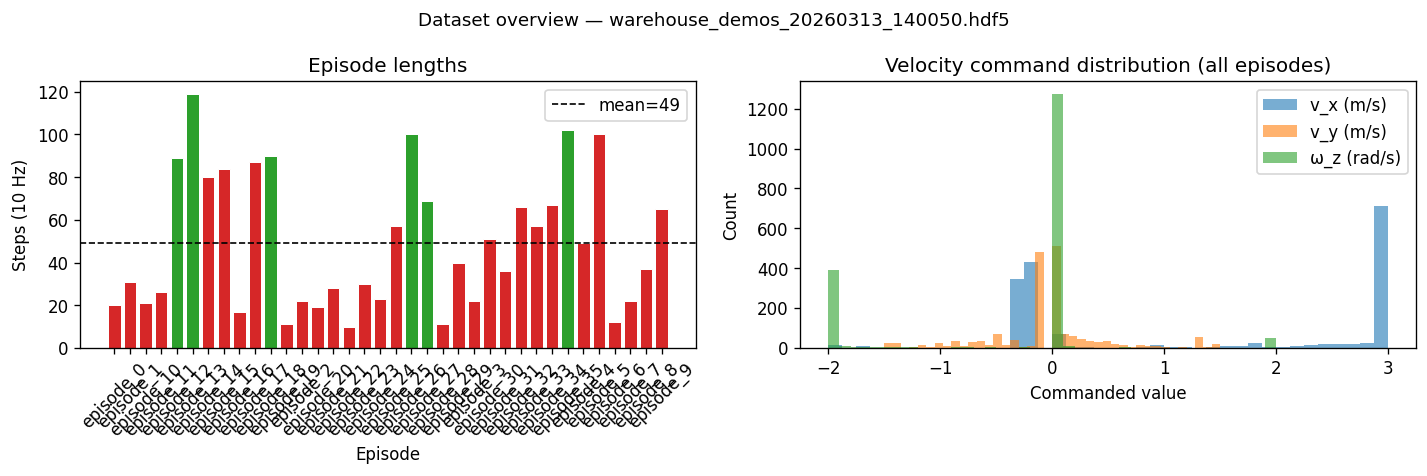

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Dataset overview — {os.path.basename(HDF5_PATH)}", fontsize=11)

# ── Episode lengths bar chart ─────────────────────────────────────────────────
ax = axes[0]
lengths = [e["episode_length"] for e in episodes.values()]
colors  = ["tab:green" if e["success"] else "tab:red" for e in episodes.values()]
ax.bar(ep_keys, lengths, color=colors, edgecolor="white", linewidth=0.6)
ax.axhline(np.mean(lengths), color="black", linestyle="--", linewidth=1, label=f"mean={np.mean(lengths):.0f}")
ax.set_xlabel("Episode")
ax.set_ylabel("Steps (10 Hz)")
ax.set_title("Episode lengths")
ax.tick_params(axis="x", rotation=45)
ax.legend(handles=[
    Patch(color="tab:green", label="success"),
    Patch(color="tab:red",   label="failure"),
], loc="upper right")
ax.legend(loc="upper right")

# ── Velocity command distribution (all episodes combined) ─────────────────────
ax = axes[1]
all_cmds = np.concatenate([e["velocity_cmd"] for e in episodes.values()], axis=0)
labels  = ["v_x (m/s)", "v_y (m/s)", "ω_z (rad/s)"]
for i, label in enumerate(labels):
    ax.hist(all_cmds[:, i], bins=40, alpha=0.6, label=label)
ax.set_xlabel("Commanded value")
ax.set_ylabel("Count")
ax.set_title("Velocity command distribution (all episodes)")
ax.legend()

plt.tight_layout()
plt.show()

---
## 2 · Camera RGB Viewer

Use the slider to scrub through frames, or pick a different episode from the dropdown.

In [61]:
ep_selector = widgets.Dropdown(
    options=ep_keys,
    value=ep_keys[0],
    description="Episode:",
)
frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=episodes[ep_keys[0]]["episode_length"] - 1,
    step=1,
    description="Frame:",
    continuous_update=True,
    layout=widgets.Layout(width="500px"),
)
out_img = widgets.Output()

def update_frame(*_):
    ep  = episodes[ep_selector.value]
    t   = frame_slider.value
    rgb = ep["camera_rgb"][t]          # (H, W, 3)
    vc  = ep["velocity_cmd"][t]        # (3,)
    pos = ep["base_pose"][t, :3]       # (3,)
    frame_slider.max = ep["episode_length"] - 1
    with out_img:
        out_img.clear_output(wait=True)
        fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
        ax.imshow(rgb)
        ax.set_title(
            f"{ep_selector.value}  frame {t}/{ep['episode_length']-1}  "
            f"success={ep['success']}\n"
            f"vx={vc[0]:+.2f}  vy={vc[1]:+.2f}  wz={vc[2]:+.2f}  "
            f"pos=({pos[0]:.1f}, {pos[1]:.1f}, {pos[2]:.1f})",
            fontsize=8,
        )
        ax.axis("off")
        plt.tight_layout()
        plt.show()

def on_episode_change(change):
    ep = episodes[change["new"]]
    frame_slider.max = ep["episode_length"] - 1
    frame_slider.value = 0
    update_frame()

ep_selector.observe(on_episode_change, names="value")
frame_slider.observe(update_frame, names="value")

display(widgets.VBox([ep_selector, frame_slider, out_img]))
update_frame()

---
## 3 · XY Trajectory (Bird's-Eye View)

Top-down view of Spot's path in the warehouse for every episode.
The goal marker is shown as a green star; start/end positions are marked.

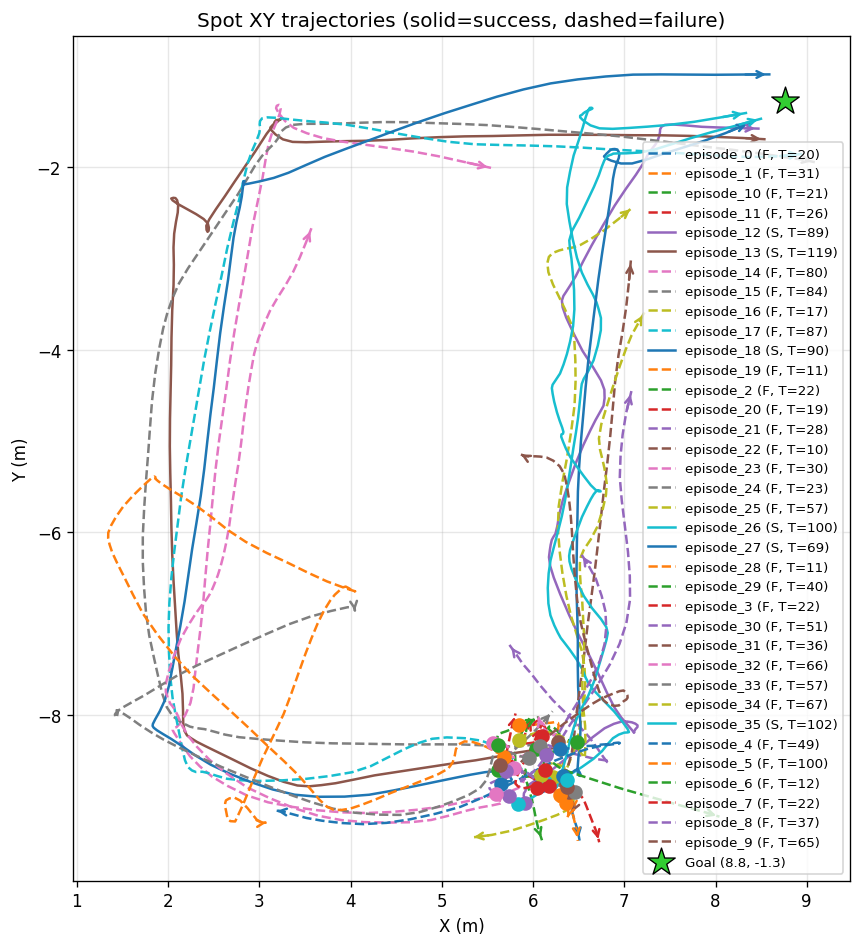

In [62]:
fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.get_cmap("tab10")

for i, (key, ep) in enumerate(episodes.items()):
    xy   = ep["base_pose"][:, :2]        # (T, 2)
    col  = cmap(i % 10)
    ls   = "-" if ep["success"] else "--"
    ax.plot(xy[:, 0], xy[:, 1], linestyle=ls, color=col, linewidth=1.5,
            label=f"{key} ({'S' if ep['success'] else 'F'}, T={ep['episode_length']})")
    # Start dot
    ax.scatter(xy[0, 0],  xy[0, 1],  marker="o", s=60,  color=col, zorder=5)
    # End arrow
    ax.annotate("", xy=(xy[-1, 0], xy[-1, 1]),
                xytext=(xy[-2, 0], xy[-2, 1]),
                arrowprops=dict(arrowstyle="->", color=col, lw=1.5))

# Goal marker (same for all episodes in this session)
goal = episodes[ep_keys[0]]["goal_position_world"]
ax.scatter(goal[0], goal[1], marker="*", s=300, color="limegreen",
           edgecolors="black", linewidths=0.8, zorder=6, label=f"Goal ({goal[0]:.1f}, {goal[1]:.1f})")

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Spot XY trajectories (solid=success, dashed=failure)")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

---
## 4 · Velocity Commands vs Actual Base Velocity (Body Frame)

Compares what you *commanded* (gamepad) with what the robot *actually achieved*,
both in the robot's body frame (from `policy_obs`).
Lag and saturation indicate how well the locomotion policy is tracking the command.

In [63]:
# Training velocity limits (shaded bands)
VEL_LIMITS = [(-2.0, 3.0), (-1.5, 1.5), (-2.0, 2.0)]
VEL_LABELS = ["v_x (m/s)", "v_y (m/s)", "ω_z (rad/s)"]

ep_dropdown = widgets.Dropdown(options=ep_keys, value=ep_keys[0], description="Episode:")
out_vel = widgets.Output()

def plot_velocity(ep_key):
    ep  = episodes[ep_key]
    T   = ep["episode_length"]
    t   = np.arange(T) / 10.0        # seconds at 10 Hz
    cmd = ep["velocity_cmd"]          # (T, 3) body frame: [v_x, v_y, omega_z]
    obs = ep["policy_obs"]            # (T, 48) — [0,1]=body lin vel, [5]=yaw rate

    fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"{ep_key} — velocity commanded vs actual (body frame)  (success={ep['success']})", fontsize=10)

    actual_signals = [obs[:, 0], obs[:, 1], obs[:, 5]]

    for i, ax in enumerate(axes):
        lo, hi = VEL_LIMITS[i]
        ax.axhspan(lo, hi, alpha=0.08, color="steelblue", label="training range")
        ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
        ax.plot(t, cmd[:, i],           color="tab:orange", linewidth=1.5, label="commanded")
        ax.plot(t, actual_signals[i],   color="tab:blue",   linewidth=1.0, alpha=0.8, label="actual")
        ax.set_ylabel(VEL_LABELS[i])
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

def on_vel_ep_change(change):
    with out_vel:
        out_vel.clear_output(wait=True)
        plot_velocity(change["new"])

ep_dropdown.observe(on_vel_ep_change, names="value")
display(ep_dropdown, out_vel)

with out_vel:
    plot_velocity(ep_keys[0])

Dropdown(description='Episode:', options=('episode_0', 'episode_1', 'episode_10', 'episode_11', 'episode_12', …

Output()

---
## 5 · Policy-Obs / Velocity-Cmd Consistency Check

`policy_obs[9:12]` must equal `velocity_cmd` exactly — they are set from the same
tensor before policy inference. Any non-zero residual indicates a data-logging bug.

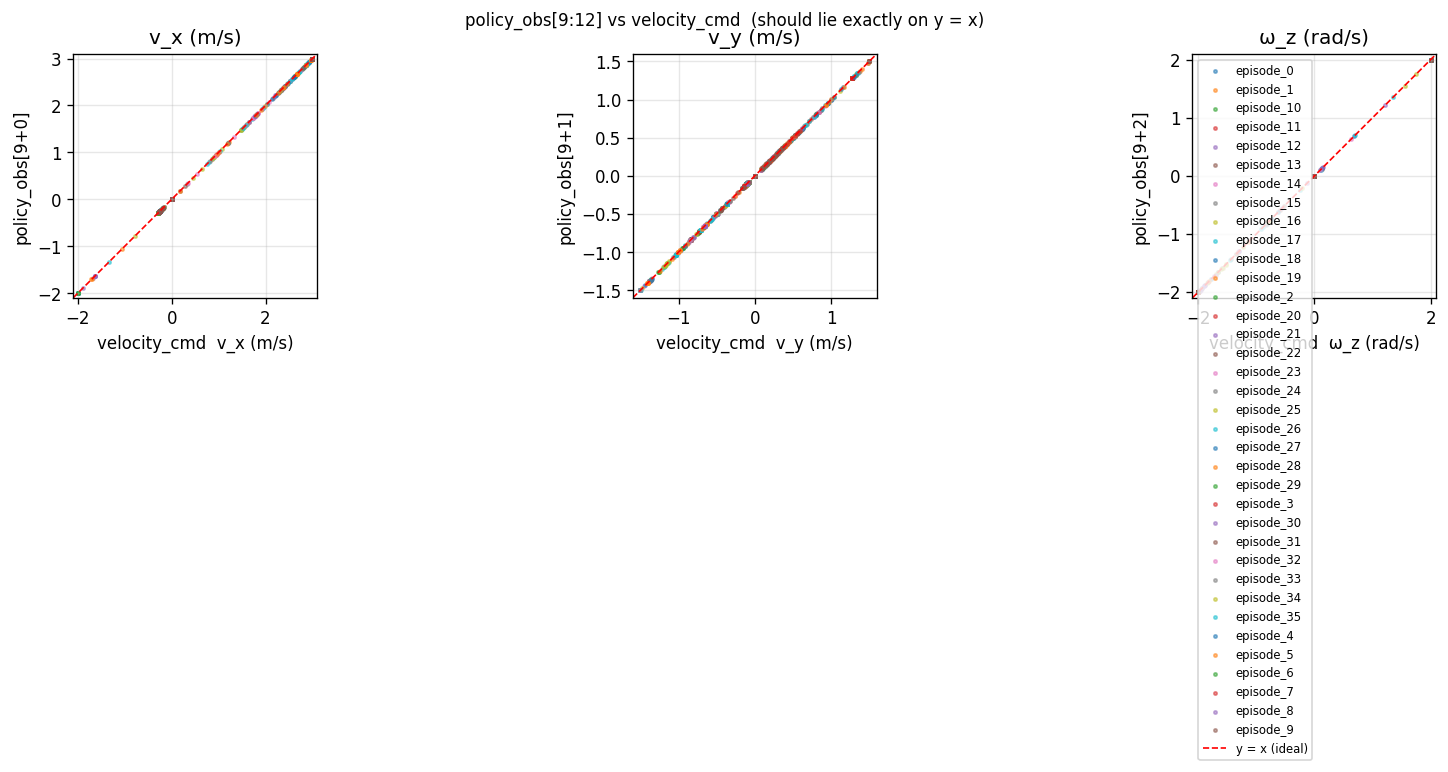

Max |policy_obs[9:12] − velocity_cmd| per episode:
  episode_0: max diff = 0.00e+00  ✓
  episode_1: max diff = 0.00e+00  ✓
  episode_10: max diff = 0.00e+00  ✓
  episode_11: max diff = 0.00e+00  ✓
  episode_12: max diff = 0.00e+00  ✓
  episode_13: max diff = 0.00e+00  ✓
  episode_14: max diff = 0.00e+00  ✓
  episode_15: max diff = 0.00e+00  ✓
  episode_16: max diff = 0.00e+00  ✓
  episode_17: max diff = 0.00e+00  ✓
  episode_18: max diff = 0.00e+00  ✓
  episode_19: max diff = 0.00e+00  ✓
  episode_2: max diff = 0.00e+00  ✓
  episode_20: max diff = 0.00e+00  ✓
  episode_21: max diff = 0.00e+00  ✓
  episode_22: max diff = 0.00e+00  ✓
  episode_23: max diff = 0.00e+00  ✓
  episode_24: max diff = 0.00e+00  ✓
  episode_25: max diff = 0.00e+00  ✓
  episode_26: max diff = 0.00e+00  ✓
  episode_27: max diff = 0.00e+00  ✓
  episode_28: max diff = 0.00e+00  ✓
  episode_29: max diff = 0.00e+00  ✓
  episode_3: max diff = 0.00e+00  ✓
  episode_30: max diff = 0.00e+00  ✓
  episode_31: max diff = 0.0

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("policy_obs[9:12] vs velocity_cmd  (should lie exactly on y = x)", fontsize=10)

for ep_key, ep in episodes.items():
    obs_slice = ep["policy_obs"][:, 9:12]   # (T, 3)
    vel_cmd   = ep["velocity_cmd"]            # (T, 3)
    for i, ax in enumerate(axes):
        ax.scatter(vel_cmd[:, i], obs_slice[:, i], s=4, alpha=0.5, label=ep_key)

axis_labels = ["v_x (m/s)", "v_y (m/s)", "ω_z (rad/s)"]
all_vals = np.concatenate([e["velocity_cmd"] for e in episodes.values()], axis=0)

for i, ax in enumerate(axes):
    lim = [all_vals[:, i].min() - 0.1, all_vals[:, i].max() + 0.1]
    ax.plot(lim, lim, "r--", linewidth=1, label="y = x (ideal)")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(f"velocity_cmd  {axis_labels[i]}")
    ax.set_ylabel(f"policy_obs[9+{i}]")
    ax.set_title(axis_labels[i])
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

axes[-1].legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

# Numeric residual
print("Max |policy_obs[9:12] − velocity_cmd| per episode:")
for ep_key, ep in episodes.items():
    diff = np.abs(ep["policy_obs"][:, 9:12] - ep["velocity_cmd"]).max()
    status = "✓" if diff < 1e-5 else "✗ MISMATCH"
    print(f"  {ep_key}: max diff = {diff:.2e}  {status}")

---
## 6 · Joint Positions Heatmap

Each row is one of the 12 Spot joints (3 per leg × 4 legs).
Large deviations from default pose indicate dynamic locomotion or falls.

In [65]:
# Approximate Spot joint names in Isaac Lab order
# FL = front-left, FR = front-right, RL = rear-left, RR = rear-right
# HX = hip-abduction, HY = hip-flexion, KN = knee
JOINT_NAMES = [
    "FL_hx", "FL_hy", "FL_kn",
    "FR_hx", "FR_hy", "FR_kn",
    "RL_hx", "RL_hy", "RL_kn",
    "RR_hx", "RR_hy", "RR_kn",
]

ep_sel2 = widgets.Dropdown(options=ep_keys, value=ep_keys[0], description="Episode:")
out_jnt  = widgets.Output()

def plot_joints(ep_key):
    ep  = episodes[ep_key]
    T   = ep["episode_length"]
    t   = np.arange(T) / 10.0
    jp  = ep["joint_pos"]    # (T, 12)
    jt  = ep["joint_targets"] # (T, 12)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{ep_key} — joint positions & targets  (success={ep['success']})", fontsize=10)

    for ax, data, title in zip(axes, [jp, jt], ["joint_pos (measured)", "joint_targets (policy output)"]):
        im = ax.imshow(
            data.T, aspect="auto", origin="lower",
            extent=[t[0], t[-1], -0.5, 11.5],
            cmap="RdBu_r", vmin=-2.5, vmax=2.5,
        )
        ax.set_yticks(np.arange(12))
        ax.set_yticklabels(JOINT_NAMES, fontsize=8)
        ax.set_xlabel("Time (s)")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label="rad")

    plt.tight_layout()
    plt.show()

def on_jnt_change(change):
    with out_jnt:
        out_jnt.clear_output(wait=True)
        plot_joints(change["new"])

ep_sel2.observe(on_jnt_change, names="value")
display(ep_sel2, out_jnt)

with out_jnt:
    plot_joints(ep_keys[0])

Dropdown(description='Episode:', options=('episode_0', 'episode_1', 'episode_10', 'episode_11', 'episode_12', …

Output()

---
## 7 · Contact Force Magnitudes

Net force magnitude (||F||) for every body in the contact sensor.
Foot bodies should show periodic loading (gait), while non-foot bodies should be near zero unless Spot fell.

In [66]:
ep_sel3  = widgets.Dropdown(options=ep_keys, value=ep_keys[0], description="Episode:")
out_cf   = widgets.Output()

def plot_contact_forces(ep_key):
    ep  = episodes[ep_key]
    T   = ep["episode_length"]
    t   = np.arange(T) / 10.0
    cf  = ep["contact_forces"]              # (T, N_bodies, 3)
    mag = np.linalg.norm(cf, axis=-1)       # (T, N_bodies)
    N   = mag.shape[1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{ep_key} — contact forces  (success={ep['success']})", fontsize=10)

    # ── Heatmap ───────────────────────────────────────────────────────────────
    ax = axes[0]
    im = ax.imshow(
        mag.T, aspect="auto", origin="lower",
        extent=[t[0], t[-1], -0.5, N - 0.5],
        cmap="hot_r", vmin=0, vmax=mag.max(),
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Body index")
    ax.set_title("Force magnitude heatmap (N)")
    plt.colorbar(im, ax=ax, label="||F|| (N)")

    # ── Top 4 highest-contact bodies (likely feet) ────────────────────────────
    ax = axes[1]
    mean_force = mag.mean(axis=0)           # (N_bodies,)
    top4 = np.argsort(mean_force)[-4:][::-1]
    for body_idx in top4:
        ax.plot(t, mag[:, body_idx], linewidth=1.2, label=f"body {body_idx} (mean={mean_force[body_idx]:.1f} N)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("||F|| (N)")
    ax.set_title("Top 4 most-loaded bodies (likely feet)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def on_cf_change(change):
    with out_cf:
        out_cf.clear_output(wait=True)
        plot_contact_forces(change["new"])

ep_sel3.observe(on_cf_change, names="value")
display(ep_sel3, out_cf)

with out_cf:
    plot_contact_forces(ep_keys[0])

Dropdown(description='Episode:', options=('episode_0', 'episode_1', 'episode_10', 'episode_11', 'episode_12', …

Output()

---
## 8 · Frame Strip — Visual Gait Sampling

Shows 8 evenly-spaced camera frames from an episode in a single row,
with the commanded velocity annotated on each frame.

In [67]:
N_FRAMES = 8

ep_sel4 = widgets.Dropdown(options=ep_keys, value=ep_keys[0], description="Episode:")
out_strip = widgets.Output()

def plot_strip(ep_key):
    ep   = episodes[ep_key]
    T    = ep["episode_length"]
    idxs = np.linspace(0, T - 1, N_FRAMES, dtype=int)

    fig, axes = plt.subplots(1, N_FRAMES, figsize=(16, 2.5))
    fig.suptitle(
        f"{ep_key} — {N_FRAMES} evenly-spaced frames  "
        f"(T={T}, success={ep['success']})",
        fontsize=9,
    )
    for ax, t_idx in zip(axes, idxs):
        ax.imshow(ep["camera_rgb"][t_idx])
        vc = ep["velocity_cmd"][t_idx]
        ax.set_title(
            f"t={t_idx/10:.1f}s\nvx={vc[0]:+.1f} vy={vc[1]:+.1f}\nwz={vc[2]:+.1f}",
            fontsize=6,
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def on_strip_change(change):
    with out_strip:
        out_strip.clear_output(wait=True)
        plot_strip(change["new"])

ep_sel4.observe(on_strip_change, names="value")
display(ep_sel4, out_strip)

with out_strip:
    plot_strip(ep_keys[0])

Dropdown(description='Episode:', options=('episode_0', 'episode_1', 'episode_10', 'episode_11', 'episode_12', …

Output()

---
## 9 · Goal-Relative Distance Over Time

Euclidean XY distance from Spot to the goal throughout each episode.
A successful episode should end near `success_radius = 0.5 m`.

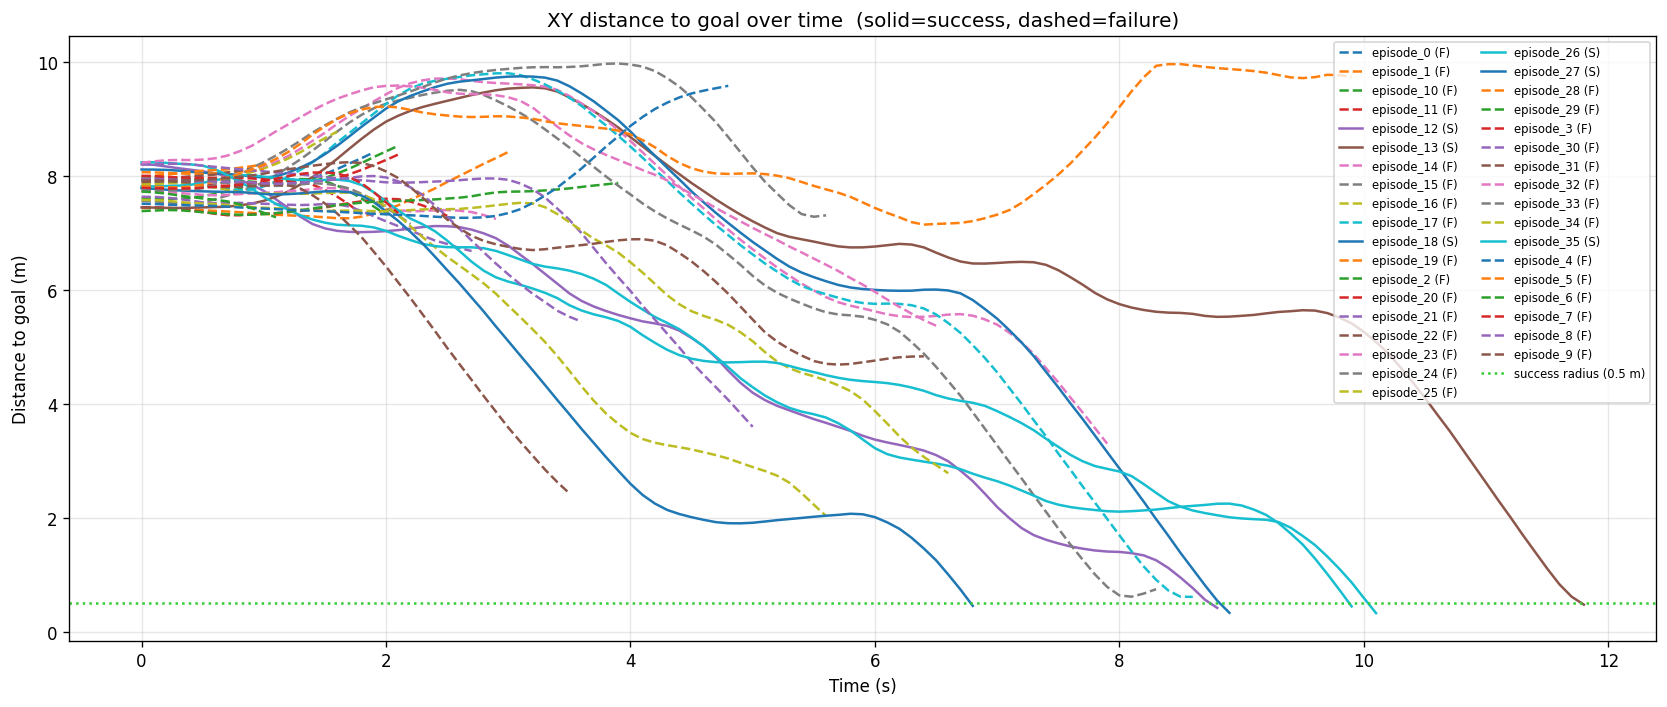

In [68]:
SUCCESS_RADIUS = 0.5   # metres, must match collect_demos.py --success_radius

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.get_cmap("tab10")

for i, (key, ep) in enumerate(episodes.items()):
    T   = ep["episode_length"]
    t   = np.arange(T) / 10.0
    gr  = ep["goal_relative"]                   # (T, 3)
    dist_xy = np.linalg.norm(gr[:, :2], axis=-1) # XY only
    col = cmap(i % 10)
    ls  = "-" if ep["success"] else "--"
    ax.plot(t, dist_xy, color=col, linestyle=ls, linewidth=1.5,
            label=f"{key} ({'S' if ep['success'] else 'F'})")

ax.axhline(SUCCESS_RADIUS, color="limegreen", linestyle=":", linewidth=1.5,
           label=f"success radius ({SUCCESS_RADIUS} m)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Distance to goal (m)")
ax.set_title("XY distance to goal over time  (solid=success, dashed=failure)")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10 · Reward Computation

Compute offline rewards for every episode using `rewards.py`.
Reward terms: time penalty, termination penalty, goal reached, goal approach,
command tracking (L2), command smoothness, non-foot body contact, uprightness.

In [69]:
import sys
import importlib

_project_root = os.path.abspath("..")
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)
if "rewards" in sys.modules:
    importlib.reload(sys.modules["rewards"])

from rewards import RewardConfig, compute_episode_rewards, compute_dataset_rewards, REWARD_COMPONENT_NAMES

cfg = RewardConfig()

if has_stored_rewards:
    # Use rewards stored in the HDF5 during collection
    print("[INFO] Using stored rewards from HDF5 (collected online)\n")
    all_rewards = {}
    for k in ep_keys:
        ep = episodes[k]
        components = {name: ep[f"reward/{name}"] for name in REWARD_COMPONENT_NAMES}
        all_rewards[k] = {
            "total": ep["reward/total"],
            "components": components,
            "config": cfg,
        }
else:
    # Compute offline from stored obs/action data
    print("[INFO] No stored rewards — computing offline\n")
    all_rewards = compute_dataset_rewards(episodes, cfg)

# Summary table
print(f"{'Episode':>12s}  {'T':>4s}  {'Success':>7s}  {'Total':>10s}  {'Mean/step':>10s}")
print("-" * 55)
for k in ep_keys:
    r = all_rewards[k]
    ep = episodes[k]
    t = r["total"]
    print(f"{k:>12s}  {ep['episode_length']:4d}  {str(ep['success']):>7s}  "
          f"{t.sum():+10.2f}  {t.mean():+10.4f}")

[INFO] Using stored rewards from HDF5 (collected online)

     Episode     T  Success       Total   Mean/step
-------------------------------------------------------
   episode_0    20    False       -9.69     -0.4846
   episode_1    31    False       -7.51     -0.2424
  episode_10    21    False      -27.88     -1.3277
  episode_11    26    False      -33.04     -1.2707
  episode_12    89     True     -111.99     -1.2583
  episode_13   119     True     -122.81     -1.0320
  episode_14    80    False      -73.42     -0.9178
  episode_15    84    False      -95.53     -1.1373
  episode_16    17    False      -35.03     -2.0606
  episode_17    87    False      -96.66     -1.1111
  episode_18    90     True      -62.35     -0.6928
  episode_19    11    False      -14.58     -1.3253
   episode_2    22    False       -9.49     -0.4316
  episode_20    19    False      -34.84     -1.8335
  episode_21    28    False      -52.91     -1.8896
  episode_22    10    False      -21.38     -2.1382
  

---
### 10a · Reward Component Breakdown (bar chart)

Mean per-step contribution of each reward component across all episodes.

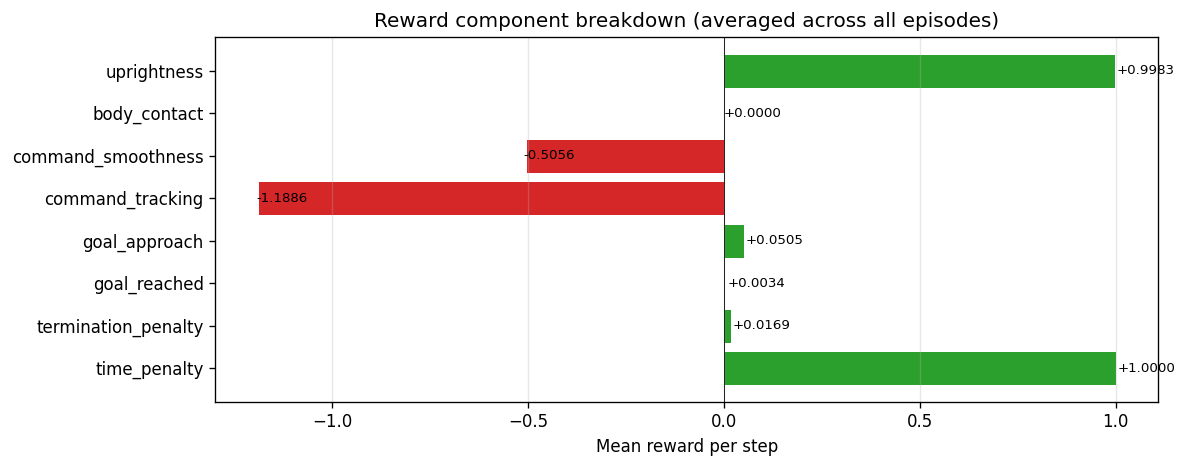

In [70]:
component_names = list(all_rewards[ep_keys[0]]["components"].keys())

# Compute grand mean of each component across all episodes
grand_means = {}
for name in component_names:
    vals = np.concatenate([all_rewards[k]["components"][name] for k in ep_keys])
    grand_means[name] = vals.mean()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tab:red" if v < 0 else "tab:green" for v in grand_means.values()]
bars = ax.barh(list(grand_means.keys()), list(grand_means.values()), color=colors,
               edgecolor="white", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Mean reward per step")
ax.set_title("Reward component breakdown (averaged across all episodes)")
ax.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, grand_means.values()):
    ax.text(bar.get_width() + 0.005 * np.sign(bar.get_width()),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

---
### 10b · Total Reward Over Time (per episode)

The total reward signal the RL agent would receive at each 10 Hz step.

In [ ]:
ep_sel_r = widgets.Dropdown(options=ep_keys, value=ep_keys[0], description="Episode:")
out_rew = widgets.Output()

def plot_reward_total(ep_key):
    r  = all_rewards[ep_key]
    ep = episodes[ep_key]
    T  = ep["episode_length"]
    t  = np.arange(T) / 10.0
    total = r["total"]

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 3]})
    fig.suptitle(f"{ep_key} — reward over time  (success={ep['success']}, "
                 f"sum={total.sum():+.1f})", fontsize=10)

    # Top: total reward
    ax = axes[0]
    ax.fill_between(t, total, 0, where=total >= 0, color="tab:green", alpha=0.4)
    ax.fill_between(t, total, 0, where=total <  0, color="tab:red",   alpha=0.4)
    ax.plot(t, total, color="black", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_ylabel("Total reward")
    ax.grid(True, alpha=0.3)

    # Bottom: stacked component breakdown
    ax = axes[1]
    for name in component_names:
        arr = r["components"][name]
        if np.abs(arr).max() < 1e-6:
            continue  # skip zero components for visual clarity
        ax.plot(t, arr, linewidth=1.2, label=name, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Component reward")
    ax.legend(fontsize=7, loc="lower left", ncol=2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def on_rew_change(change):
    with out_rew:
        out_rew.clear_output(wait=True)
        plot_reward_total(change["new"])

ep_sel_r.observe(on_rew_change, names="value")
display(ep_sel_r, out_rew)

with out_rew:
    plot_reward_total(ep_keys[0])

Dropdown(description='Episode:', options=('episode_0', 'episode_1', 'episode_10', 'episode_11', 'episode_12', …

Output()

---
### 10c · Command Tracking Detail

Per-axis comparison of commanded vs achieved velocity, with the L2 tracking
error overlaid. This is the primary dense reward signal.

In [72]:
ep_sel_ct = widgets.Dropdown(options=ep_keys, value=ep_keys[0], description="Episode:")
out_ct = widgets.Output()

AXIS_LABELS = ["v_x (m/s)", "v_y (m/s)", "ω_z (rad/s)"]
ACHIEVED_IDX = [0, 1, 5]  # policy_obs indices for [v_x, v_y, omega_z] in robot frame

def plot_command_tracking(ep_key):
    ep  = episodes[ep_key]
    T   = ep["episode_length"]
    t   = np.arange(T) / 10.0
    cmd = ep["velocity_cmd"]
    obs = ep["policy_obs"]
    achieved = np.column_stack([obs[:, i] for i in ACHIEVED_IDX])
    err = np.linalg.norm(cmd - achieved, axis=-1)

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(f"{ep_key} — command tracking detail  (success={ep['success']})", fontsize=10)

    for i in range(3):
        ax = axes[i]
        ax.plot(t, cmd[:, i],      color="tab:orange", linewidth=1.5, label="commanded")
        ax.plot(t, achieved[:, i], color="tab:blue",   linewidth=1.0, alpha=0.8, label="achieved")
        ax.fill_between(t, cmd[:, i], achieved[:, i], alpha=0.15, color="tab:red")
        ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
        ax.set_ylabel(AXIS_LABELS[i])
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.fill_between(t, err, 0, color="tab:red", alpha=0.4)
    ax.plot(t, err, color="tab:red", linewidth=0.8)
    ax.set_ylabel("L2 tracking error")
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"mean error = {err.mean():.3f},  max = {err.max():.3f}", fontsize=9)

    plt.tight_layout()
    plt.show()

def on_ct_change(change):
    with out_ct:
        out_ct.clear_output(wait=True)
        plot_command_tracking(change["new"])

ep_sel_ct.observe(on_ct_change, names="value")
display(ep_sel_ct, out_ct)

with out_ct:
    plot_command_tracking(ep_keys[0])

Dropdown(description='Episode:', options=('episode_0', 'episode_1', 'episode_10', 'episode_11', 'episode_12', …

Output()

---
### 10d · Cumulative Return per Episode

Running sum of total reward — shows the trajectory of return that an RL
agent would receive.  Steeper downward slopes indicate problematic regions.

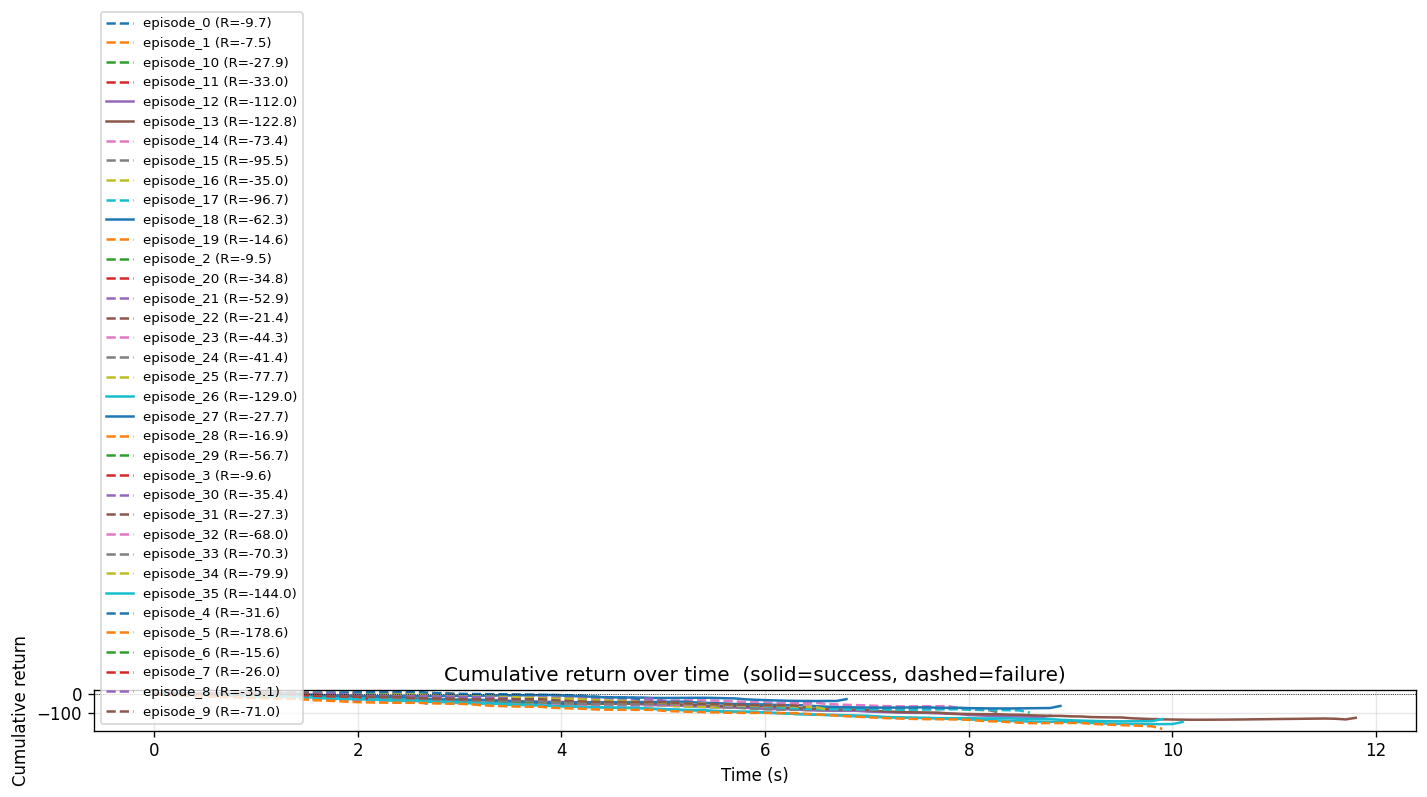

In [73]:
fig, ax = plt.subplots(figsize=(12, 4))
cmap = plt.get_cmap("tab10")

for i, k in enumerate(ep_keys):
    r = all_rewards[k]
    T = episodes[k]["episode_length"]
    t = np.arange(T) / 10.0
    cumsum = np.cumsum(r["total"])
    col = cmap(i % 10)
    ls  = "-" if episodes[k]["success"] else "--"
    ax.plot(t, cumsum, color=col, linestyle=ls, linewidth=1.5,
            label=f"{k} (R={cumsum[-1]:+.1f})")

ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Cumulative return")
ax.set_title("Cumulative return over time  (solid=success, dashed=failure)")
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11 · Body Orientation / Tilt

**Top plot:** Roll and pitch angles extracted from the `base_pose` quaternion.
Roll = left/right tilt, pitch = forward/backward tilt.  Spikes typically
precede a fall.

**Bottom plot:** Projected gravity vector components from `policy_obs[6:9]`.
When upright this is `(0, 0, −1)`.  Nonzero x/y components indicate tilt
direction in the body frame — this is what the low-level policy "sees".

In [74]:
def quat_wxyz_to_rpy(q):
    """Convert (T, 4) wxyz quaternions to (T, 3) roll-pitch-yaw in degrees."""
    w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    # Roll (x-axis rotation)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)
    # Pitch (y-axis rotation)
    sinp = 2.0 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)
    # Yaw (z-axis rotation)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)
    return np.degrees(np.column_stack([roll, pitch, yaw]))

ep_sel_tilt = widgets.Dropdown(options=ep_keys, value=ep_keys[0], description="Episode:")
out_tilt = widgets.Output()

def plot_tilt(ep_key):
    ep  = episodes[ep_key]
    T   = ep["episode_length"]
    t   = np.arange(T) / 10.0
    quat = ep["base_pose"][:, 3:]        # (T, 4) wxyz
    rpy  = quat_wxyz_to_rpy(quat)        # (T, 3) degrees
    grav = ep["policy_obs"][:, 6:9]      # (T, 3) projected gravity in body frame

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"{ep_key} — body orientation  (success={ep['success']})", fontsize=10)

    # ── Roll / Pitch from quaternion ──────────────────────────────────────
    ax = axes[0]
    ax.plot(t, rpy[:, 0], color="tab:blue",   linewidth=1.5, label="Roll (left/right)")
    ax.plot(t, rpy[:, 1], color="tab:orange",  linewidth=1.5, label="Pitch (fwd/back)")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.axhspan(-5, 5, alpha=0.06, color="green", label="±5° safe zone")
    ax.set_ylabel("Angle (degrees)")
    ax.set_title("Roll & Pitch from base quaternion")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

    # ── Projected gravity vector ──────────────────────────────────────────
    ax = axes[1]
    ax.plot(t, grav[:, 0], color="tab:red",    linewidth=1.2, label="grav_x (roll tilt)")
    ax.plot(t, grav[:, 1], color="tab:purple",  linewidth=1.2, label="grav_y (pitch tilt)")
    ax.plot(t, grav[:, 2], color="tab:gray",   linewidth=1.2, label="grav_z (uprightness)")
    ax.axhline(-1.0, color="black", linewidth=0.5, linestyle=":", alpha=0.5)
    ax.axhline(0.0, color="black", linewidth=0.5, linestyle=":")
    ax.set_ylabel("Projected gravity (body frame)")
    ax.set_xlabel("Time (s)")
    ax.set_title("Projected gravity — policy_obs[6:9]  (grav_z ≈ −1 when upright)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def on_tilt_change(change):
    with out_tilt:
        out_tilt.clear_output(wait=True)
        plot_tilt(change["new"])

ep_sel_tilt.observe(on_tilt_change, names="value")
display(ep_sel_tilt, out_tilt)

with out_tilt:
    plot_tilt(ep_keys[0])

Dropdown(description='Episode:', options=('episode_0', 'episode_1', 'episode_10', 'episode_11', 'episode_12', …

Output()